# Basis Sets in Electronic Structure Theory

---

## Motivation

In electronic structure calculations, we rarely solve the Schrödinger equation exactly. Instead, we approximate the wavefunction using a finite set of basis functions. The choice of basis set is one of the most important decisions in quantum chemistry—it directly controls accuracy, computational cost, and even qualitative conclusions.

In previous lessons, we used minimal basis sets (e.g., STO-3G) to describe molecules like H$_2$. While these are computationally efficient, they often lack the flexibility needed to accurately describe bonding, polarization, and electron correlation.

This lesson explores how basis sets are constructed, how they are systematically improved, and how they influence calculated molecular properties.

---

## Learning Goals

By the end of this lesson, you should be able to:

1. Explain what a basis set is and why it is needed in quantum chemistry.
2. Distinguish between Slater-type orbitals (STOs) and Gaussian-type orbitals (GTOs).
3. Understand the meaning of common basis set names (e.g., STO-3G, 6-31G, cc-pVDZ).
4. Describe the role of:
   - split-valence basis sets
   - polarization functions
   - diffuse functions
5. Predict how increasing basis set size affects energy and computational cost.
6. Perform and compare calculations with different basis sets in WebMO or Python.

---

## Basis Sets/Basis Functions 

Basis functions are used throughout data science to approximate a function.  Typical applications are for smoothing data or simplifying further math.  The basic idea is to pick a set of functions $\{g_i\}$ that can be used to express another function, $f$, in an expansion.  We will restrict this discussion to functions of one variable and linear coefficients in the expansion.  This allows us to write $f(x)$ as a linear combination of functions $\{g_i(x)\}$,

$f(x) = \sum_{i=0}^\infty c_ig_i(x)$.

This equality is only exact for certain sets of functions.  This is analagous to basis sets of vector spaces.  Rather than go into the details of the math of expansions and spanning spaces, we will provide two standard examples of $\{g_i\}$s: polynomials and gaussians.

### Polynomial basis functions

The idea is to express some function $f(x)$ as a linear combination of polynomials.  This is exact in the limit of infinite powers.  This can be expressed as $g_i(x) = x^i$.  Thus we get

$f(x) = \sum_{i=0}^\infty c_ix^i = c_0 + c_1x + c_2x^2 + c_3x^3...$.

If we truncate this expansion at $i=1$ we get a linear approximation of $f$,

$f(x) \approx c_0 + c_1x$.

Fitting of these linear coefficients, $c_0$ and $c_1$, is commonly reffered to as linear regression.

### Example: Linear Regression

As an example of linear regression we will utilize a concoted data set and then fit these points to a line.  Each "data point" represents an ordered pair $(x,f(x))$.  If we have two data points we would have two depedent linear equations

$ f(x_1) = c_0 + c_1x_1 \\ f(x_2) = c_0 + c_1x_2.$

With only two points, we can solve for $c_0$ and $c_1$ exactly.  This simply equates to two points determine a line.  Note that this can also be expressed as a matrix equation:

$\begin{bmatrix} f(x_1) \\ f(x_2) \end{bmatrix} = \begin{bmatrix} c_0 + c_1x_1 \\ c_0 + c_1x_2 \end{bmatrix} = \begin{bmatrix} 1 & x_1 \\ 1 & x_2 \end{bmatrix}  \begin{bmatrix} c_0 \\ c_1 \end{bmatrix} $.

The right-hand most expression is referred to as the coefficient matrix multiplied by the solution vector.  The solution vector can be solved for by left multiplying the expression by the inverse of the coefficient matrix

$\begin{bmatrix} c_0 \\ c_1 \end{bmatrix} = \begin{bmatrix} 1 & x_1 \\ 1 & x_2 \end{bmatrix}^{-1}\begin{bmatrix} f(x_1) \\ f(x_2)\end{bmatrix}$.

For an overdetermined set of linear equations we can solve for the solution vector (set of coefficients $\{c_i\}$) using a least squares algorithm.  The problem is usually set up as

$\mathbf{A}\mathbf{x} = \mathbf{b}$, 

where $\mathbf{A}$ is the coefficient matrix, $\mathbf{x}$ is the solution vector and $\mathbf{b}$ is the $f(x)$ vector similar to above.  

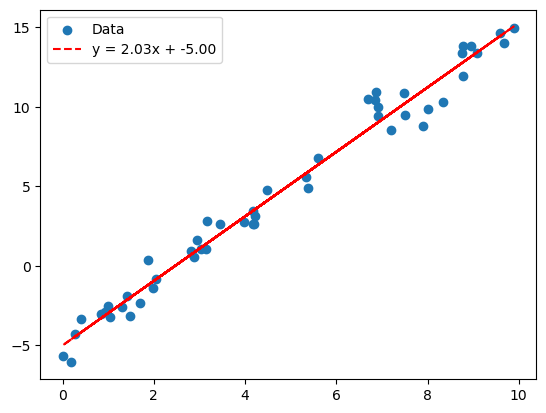

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# first generate a "data set"
rng = np.random.RandomState(1)
x = 10 * rng.rand(50)
y = 2 * x - 5 + rng.randn(50)

# now we need to generate the coefficient matrix
A = np.stack((x, np.ones(x.size)), axis=1)

# use numpy least squares routine
cs = np.linalg.lstsq(A, y, rcond=None)[0]

# extract slope and intercept
m, b = cs

# create label string (formatted nicely)
label = f"y = {m:.2f}x + {b:.2f}"

# plotting
plt.scatter(x, y, label="Data")
plt.plot(x, m * x + b, 'r--', label=label)

plt.legend()
plt.show()

### Example: Polynomial Regression

We could truncate past second order to get a polynomial fit.   A general Nth order polynomial approximation for $f$ is given as

$f(x) \approx \sum_{i=0}^N c_ix^i = c_0 + c_1x + c_2x^2 + c_3x^3 + ... + c_Nx^N$.

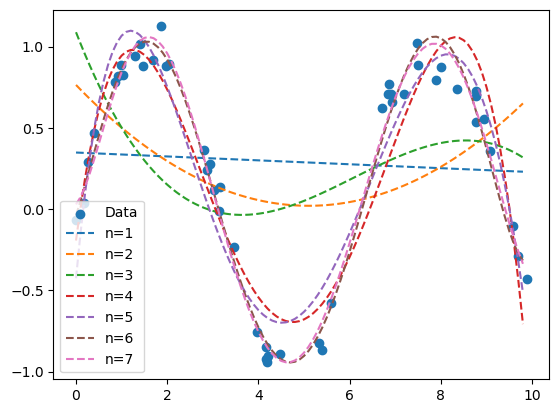

In [2]:
# code to do successive polynomial fits
maxN = 7 # maximum order of polynomial - change to increase or decrease maximum order of polynomial
# polynomial function compute polynomial value of x using coefficient cs
def poly(x,cs):
    f=0.0
    for i in range(cs.size):
        f += cs[i]*x**i
    return f
# generate sinusoidal "data"
rng = np.random.RandomState(1)
x = 10 * rng.rand(50)
y = np.sin(x) + 0.1 * rng.randn(50)
# plot data
plt.scatter(x, y,label="Data")
xfit = np.arange(np.amin(x),np.amax(x),0.1)
# perform successive polynomial fits
A = np.ones(x.size)
for i in range(1,maxN+1):
    A = np.column_stack((A,np.power(x,i)))
    cs = np.linalg.lstsq(A,y,rcond=None)[0]
    label = "n="+str(i)
    plt.plot(xfit, poly(xfit,cs),'--',label=label)
plt.legend()
plt.show()

## What is a Basis Set in Electronic Structure Calcualtions?

In the Linear Combination of Atomic Orbitals (LCAO) approach, molecular orbitals are written as:

$$\psi_i = \sum_\mu c_{\mu i} \phi_\mu$$

where $\{\phi_\mu\}$ are **basis functions**.

Rather than solving for an arbitrary function, we restrict the solution to a finite space spanned by these basis functions.

### Key Idea:
- Larger/more flexible basis → more accurate wavefunction
- But also → higher computational cost

---

## STO vs GTO

### Slater-Type Orbitals (STOs)

$$\phi(r) \sim e^{-\zeta r}$$

Pros:
- Correct cusp at nucleus
- Physically realistic decay

Cons:
- Integrals are difficult to compute

### Gaussian-Type Orbitals (GTOs)

$$\phi(r) \sim e^{-\alpha r^2}$$

Pros:
- Integrals are analytically tractable
- Much faster computations

Cons:
- Incorrect behavior near nucleus

### Solution:
- Use **contracted Gaussians** to approximate STOs

---

## Minimal Basis Sets

A **minimal basis set** uses one basis function per atomic orbital.

Example:
- STO-3G

### Meaning of STO-3G:
- STO: Slater-type orbital approximation
- 3G: each orbital is represented by 3 Gaussian functions

### Important Clarification:
STO-3G vs STO-6G:
- Same number of orbitals
- STO-6G uses more Gaussians → better approximation (not larger in dimensionality)

---

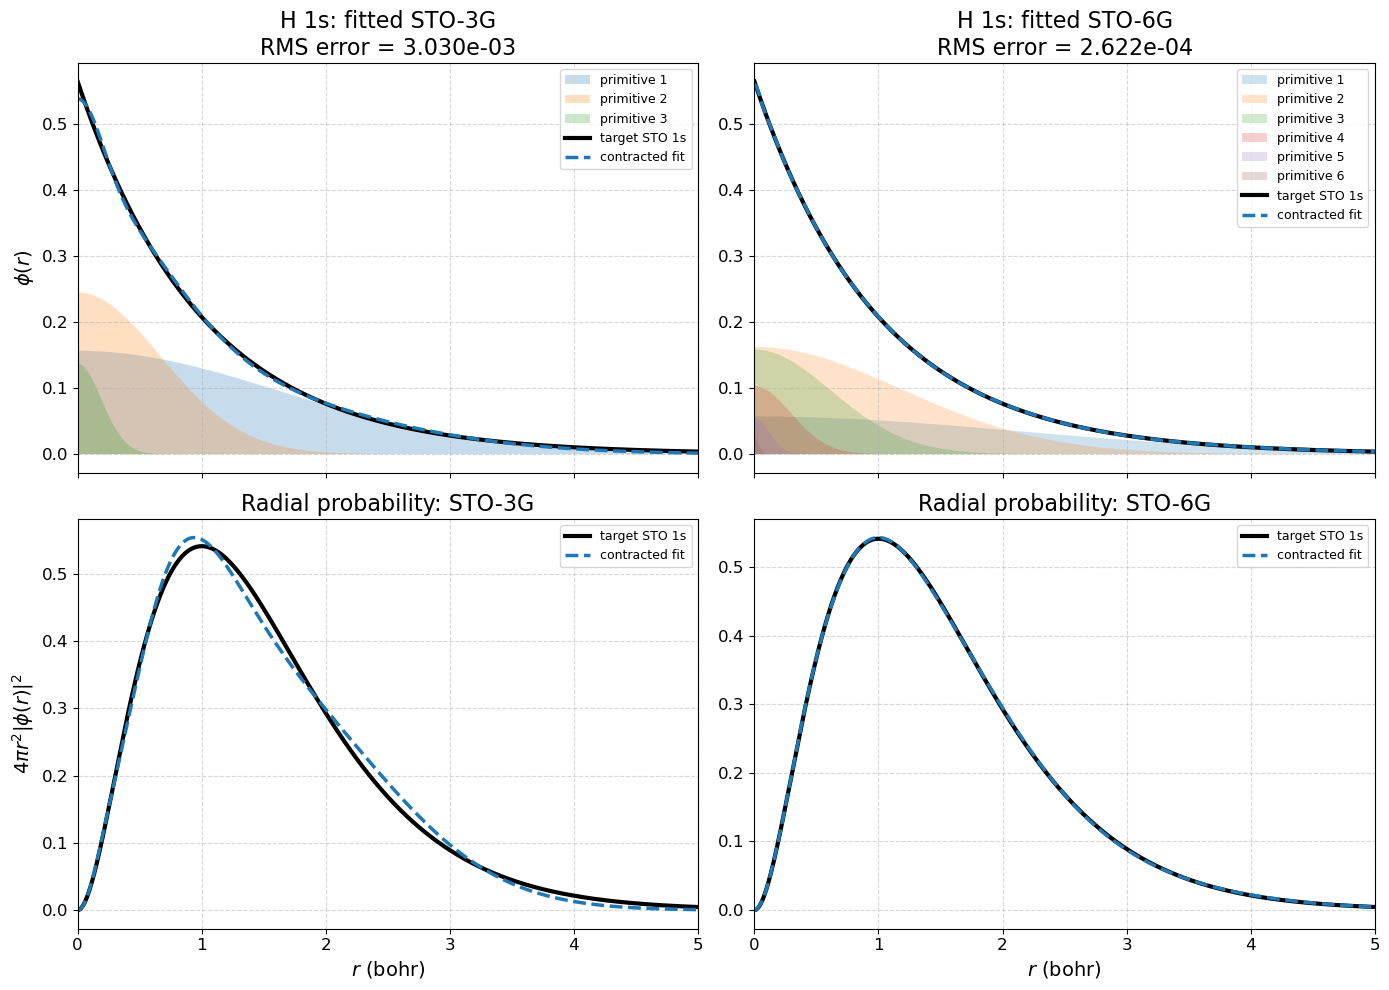

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# --------------------------------------------------
# target STO and Gaussian basis functions
# --------------------------------------------------
def sto_1s(zeta, r):
    """Normalized hydrogen-like 1s Slater-type orbital."""
    return np.sqrt(zeta**3 / np.pi) * np.exp(-zeta * r)

def primitive_gaussian(alpha, r):
    """Normalized s-type primitive Gaussian."""
    return (2.0 * alpha / np.pi)**0.75 * np.exp(-alpha * r**2)

def contracted_gaussian(alphas, coeffs, r):
    """Linear combination of primitive Gaussians."""
    val = np.zeros_like(r)
    for a, c in zip(alphas, coeffs):
        val += c * primitive_gaussian(a, r)
    return val

def primitive_contributions(alphas, coeffs, r):
    """Individual primitive contributions c_i g_i(r)."""
    return [c * primitive_gaussian(a, r) for a, c in zip(alphas, coeffs)]

# --------------------------------------------------
# fitting routine
# --------------------------------------------------
def fit_sto_ng(n, zeta=1.0, rmax=6.0, npts=5000):
    """
    Fit an n-Gaussian contracted function to the STO 1s target.
    Returns exponents, coefficients, radial grid, target, fit, RMS error.
    """
    r = np.linspace(0.0, rmax, npts)
    target = sto_1s(zeta, r)

    alpha0 = np.logspace(-1, 1.5, n)
    coeff0 = np.ones(n) / n
    x0 = np.concatenate([np.log(alpha0), coeff0])

    def residuals(params):
        log_alphas = params[:n]
        coeffs = params[n:]
        alphas = np.exp(log_alphas)
        fit = contracted_gaussian(alphas, coeffs, r)
        return fit - target

    result = least_squares(residuals, x0, max_nfev=50000)

    alphas = np.exp(result.x[:n])
    coeffs = result.x[n:]

    idx = np.argsort(alphas)
    alphas = alphas[idx]
    coeffs = coeffs[idx]

    fit = contracted_gaussian(alphas, coeffs, r)
    rms = np.sqrt(np.mean((fit - target)**2))

    return alphas, coeffs, r, target, fit, rms

# --------------------------------------------------
# plotting helper
# --------------------------------------------------
def style_axis(ax, xlabel=None, ylabel=None, title=None):
    ax.grid(True, linestyle='--', alpha=0.5)
    if title is not None:
        ax.set_title(title, fontsize=16)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=14)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=14)
    ax.tick_params(axis='both', labelsize=12)

# --------------------------------------------------
# fit STO-3G and STO-6G numerically
# --------------------------------------------------
alpha3, coeff3, r, target, fit3, rms3 = fit_sto_ng(3, zeta=1.0)
alpha6, coeff6, _, _, fit6, rms6 = fit_sto_ng(6, zeta=1.0)

prims3 = primitive_contributions(alpha3, coeff3, r)
prims6 = primitive_contributions(alpha6, coeff6, r)

# radial probabilities
P_target = 4.0 * np.pi * r**2 * target**2
P_fit3   = 4.0 * np.pi * r**2 * fit3**2
P_fit6   = 4.0 * np.pi * r**2 * fit6**2

# --------------------------------------------------
# make 2x2 figure
# --------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex='col')

# ---------------- top-left: STO-3G wavefunction ----------------
ax = axes[0, 0]
style_axis(
    ax,
    ylabel=r"$\phi(r)$",
    title=f"H 1s: fitted STO-3G\nRMS error = {rms3:.3e}"
)

for i, p in enumerate(prims3, start=1):
    ax.fill_between(r, 0.0, p, alpha=0.25, label=f"primitive {i}")

ax.plot(r, target, color='black', lw=3, label="target STO 1s")
ax.plot(r, fit3, color='tab:blue', lw=2.5, ls='--', label="contracted fit")
ax.set_xlim(0, 5)
ax.legend(fontsize=9, loc="best")

# ---------------- top-right: STO-6G wavefunction ----------------
ax = axes[0, 1]
style_axis(
    ax,
    title=f"H 1s: fitted STO-6G\nRMS error = {rms6:.3e}"
)

for i, p in enumerate(prims6, start=1):
    ax.fill_between(r, 0.0, p, alpha=0.22, label=f"primitive {i}")

ax.plot(r, target, color='black', lw=3, label="target STO 1s")
ax.plot(r, fit6, color='tab:blue', lw=2.5, ls='--', label="contracted fit")
ax.set_xlim(0, 5)
ax.legend(fontsize=9, loc="best")

# ---------------- bottom-left: STO-3G probability ----------------
ax = axes[1, 0]
style_axis(
    ax,
    xlabel=r"$r$ (bohr)",
    ylabel=r"$4\pi r^2 |\phi(r)|^2$",
    title="Radial probability: STO-3G"
)

ax.plot(r, P_target, color='black', lw=3, label="target STO 1s")
ax.plot(r, P_fit3, color='tab:blue', lw=2.5, ls='--', label="contracted fit")
ax.set_xlim(0, 5)
ax.legend(fontsize=9, loc="best")

# ---------------- bottom-right: STO-6G probability ----------------
ax = axes[1, 1]
style_axis(
    ax,
    xlabel=r"$r$ (bohr)",
    title="Radial probability: STO-6G"
)

ax.plot(r, P_target, color='black', lw=3, label="target STO 1s")
ax.plot(r, P_fit6, color='tab:blue', lw=2.5, ls='--', label="contracted fit")
ax.set_xlim(0, 5)
ax.legend(fontsize=9, loc="best")

plt.tight_layout()
plt.show()

## Split-Valence (aka double zeta) Basis Sets

Minimal basis sets are too rigid, especially for valence electrons.

### Idea:
Use multiple functions to describe valence orbitals.

A common nomenclature for these basis is, e.g 6-31G.  These are called Pople basis sets.  6-31G means that each core orbital is approximated by a single "6"-contracted Gaussian basis funciton while each valence oribtal is split into two basis funcitons, one that is a "3"-contracted Gaussian function and another that is a single Gaussian.


Example 1: 6-31G

- Core orbitals: 6 Gaussians
- Valence orbitals:
  - 3 Gaussians (inner part)
  - 1 Gaussian (outer part)

Example 2: 3-21G

- Core orbitals: 3 Gaussians
- Valence orbitals:
  - 2 Gaussians (inner part)
  - 1 Gaussian (outer part)

### Why?
- Allows orbitals to expand/contract during bonding

### Example: A Carbon Atom in 6-31G

- Carbon has 1 core spatial orbital: The 1s orbital is approximated as a single basis function (which is a 6 Gaussian contraction)
- Carbon has 4 valence orbitals:
    - 2s obital is approximated by 2 functions: A 3 Gaussian contraction inner part and a 1 Gaussian outer part
    - 3 2p orbitals each approximation by 2 functions: A 3 Gaussian contraction inner part and a 1 Gaussian outer part
- Carbon has 1 + 4*2 = 9 basis functions

---

### Triple Zeta Basis Sets

Even double zeta basis sets are sometimes not flexible enough to describe the valence orbitals.

### Idea:

Add another basis function to the valence orbitals.  In the Pople nomenclature, these look like, e.g. 6-311G.


Example 1: 6-311G

- Core orbitals: 6 Gaussians
- Valence orbitals:
  - 3 Gaussians (inner part)
  - 1 Gaussian (outer part)
  - 1 Gaussian (outer part)

### Example A Carbon Atom in 6-311G

- Carbon has 1 core spatial orbital: The 1s orbital is approximated as a single basis function (which is a 6 Gaussian contraction)
- Carbon has 4 valence orbitals:
    - 2s obital is approximated by 2 functions: A 3 Gaussian contraction inner part, a 1 Gaussian outer part, and another a 1 Gaussian outer part
    - 3 2p orbitals each approximation by 2 functions: A 3 Gaussian contraction inner part, a 1 Gaussian outer part, and another a 1 Gaussian outer part
- Carbon has 1 + 4*3 = 13 basis functions in 6-311G basis

---

## Polarization Functions

Polarization functions allow orbitals to change shape.

Example:
- Add d-functions to carbon
- Add p-functions to hydrogen

Notation:
- 6-31G(d)
- 6-31G(d,p)

### Physical Meaning:
- Enables directional bonding
- Critical for:
  - molecular geometry
  - reaction barriers

### Example: A Carbon Atom in 6-31G(d)

- Carbon has 1 core spatial orbital: The 1s orbital is approximated as a single basis function (which is a 6 Gaussian contraction)
- Carbon has 4 valence orbitals:
    - 2s obital is approximated by 2 functions: A 3 Gaussian contraction inner part and a 1 Gaussian outer part
    - 3 2p orbitals each approximation by 2 functions: A 3 Gaussian contraction inner part and a 1 Gaussian outer part
- We add 6 d-like functions (should be five but mathematically easier to add six)
- Carbon has 1 + 4*2 + 6 = 15 basis functions

---

## Diffuse Functions

Diffuse functions describe electrons far from the nucleus.

Notation:
- 6-31+G
- 6-31++G

### Important for:
- Anions
- Excited states
- Weak interactions

---

## Correlation-Consistent Basis Sets

Developed by Dunning and all include polarization functions:

- cc-pVDZ (double-zeta)
- cc-pVTZ (triple-zeta)
- cc-pVQZ (quadruple-zeta)

### Key Idea:
Systematically converge toward the complete basis set (CBS) limit.

---

## Key Trends

### As basis set size increases:

- Energy decreases (variational principle)
- Accuracy improves
- Computational cost increases rapidly

---

## In-Class Exercise

### Exercise 1
How many basis functions on a Nitrogen atom for the following basis sets?
- STO-3G
- 6-31G
- 6-31G(d)